In [1]:
%reset
import numpy as np
import math
import matplotlib.image as mpimg
import scipy as sp
from scipy.optimize import curve_fit                                                                                                                                                                                                       
import scipy.optimize as opt 
from skimage import color
from scipy import fftpack
from scipy import ndimage
from numpy import pi, r_
from pylab import figure, cm
from matplotlib.colors import LogNorm

import os
from skimage import color
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import matplotlib.colors as colors

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


I:\US200_data\Nion Swift Project 20250725 Data\analysis
(4096, 4096)


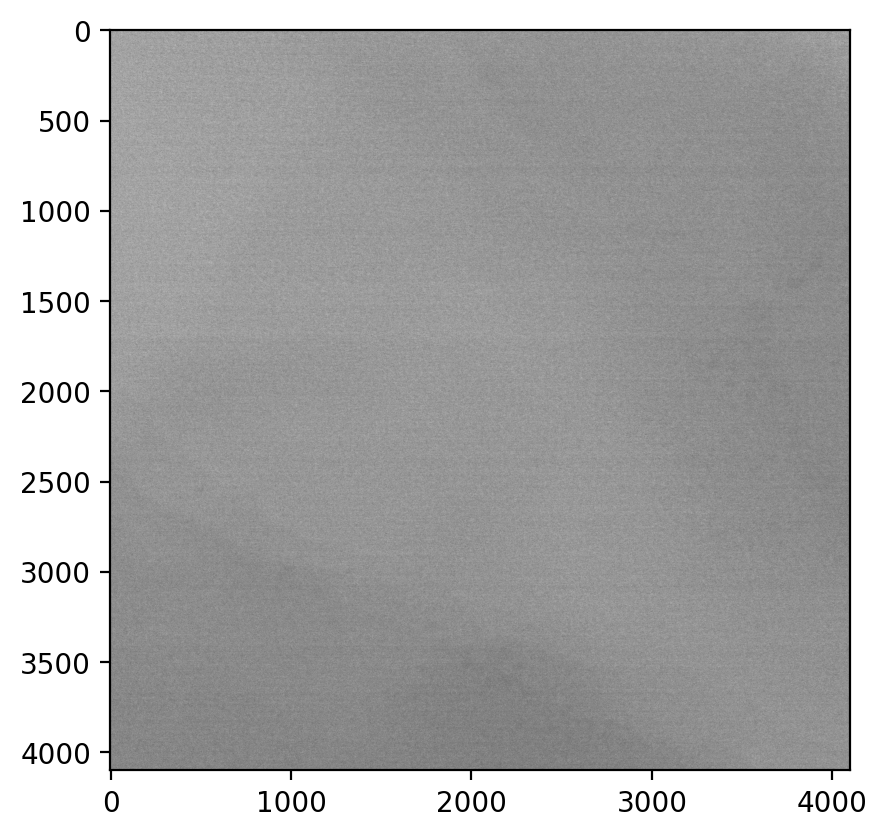

In [36]:
%cd "I:\\US200_data\\Nion Swift Project 20250725 Data\\analysis"
my_data = np.load('SuperScan-c-37.npy')
size=128
print(my_data.shape)
NpixX=my_data.shape[0]
NpixY=my_data.shape[1]
tmp=my_data
fig,ax = plt.subplots(1,dpi=200)
ax.imshow(tmp,cmap='Greys_r')
plt.show()

In [3]:
#functions to make fft int map

def getpatch(i,j,tile,step):
    #returns image patch corresponding to grid index
    xmin, xmax = step*i, step*i+tile
    ymin, ymax = step*j, step*j+tile
    Z=my_data[xmin:xmax,ymin:ymax]
    return Z

def fftpatch(Z):
    #returns properly shifted fft of the patch
    f = np.fft.fft2(Z)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.abs(fshift)*np.abs(fshift)
    return magnitude_spectrum

def gaus_pk(t,a,b,c,d):
    return a * np.exp(-b * (t-c) * (t-c)) + d

def fftint(fftpatch, tile, rmin, rmax):
    #returns integrated fft intensity in a given range of radii
    y,x = np.indices((fftpatch.shape)) # first determine radii of all pixels
    r = np.sqrt((x-tile/2)**2+(y-tile/2)**2)
    ind = np.argsort(r.flat) # get sorted indices
    sr = r.flat[ind] # sorted radii
    sim = fftpatch.flat[ind] # image values sorted by radii
    sr=sr*4
    ri = sr.astype(np.int32) # integer part of radii (bin size = 0.25)
    ri=ri/4
    # determining distance between changes
    deltar = ri[1:] - ri[:-1] # assume all radii represented
    rind = np.where(deltar)[0] # location of changed radius
    nr = rind[1:] - rind[:-1] # number in radius bin
    csim = np.cumsum(sim, dtype=np.float64) # cumulative sum to figure out sums for each radii bin
    tbin = csim[rind[1:]] - csim[rind[:-1]] # sum for image values in radius bins
    fft_int=0
    for i in range(rmin, rmax+1):
        fft_int=fft_int+tbin[i]
    return fft_int

def profpeak(fftpatch, tile, rmin, rmax):
    #returns result of fft profile peak fit in a given range of radii
    sizeP=size/NpixX*tile
    y,x = np.indices((fftpatch.shape)) # first determine radii of all pixels
    r = np.sqrt((x-tile/2)**2+(y-tile/2)**2)
    ind = np.argsort(r.flat) # get sorted indices
    sr = r.flat[ind] # sorted radii
    sim = fftpatch.flat[ind] # image values sorted by radii
    sr=sr*8
    ri = sr.astype(np.int32) # integer part of radii (bin size = 0.25)
    ri=ri/8
    # determining distance between changes
    deltar = ri[1:] - ri[:-1] # assume all radii represented
    rind = np.where(deltar)[0] # location of changed radius
    nr = rind[1:] - rind[:-1] # number in radius bin
    csim = np.cumsum(sim, dtype=np.float64) # cumulative sum to figure out sums for each radii bin
    tbin = csim[rind[1:]] - csim[rind[:-1]] # sum for image values in radius bins
    radialprofile = tbin/nr
    X=np.arange(rmin,rmax,1)
    Y=radialprofile[rmin:rmax]
    #print(X.shape, Y.shape)
    try:
        opt_parms, parm_cov = sp.optimize.curve_fit(gaus_pk, X, Y, p0=None, sigma=None, absolute_sigma=False, check_finite=True, bounds=([0.,0.,rmin,-(math.inf)], [math.inf, math.inf, rmax, math.inf]), method=None, jac=None) 
        a,b,c,d= opt_parms
        dsp=(2/((c*10)/size))
        #print("Got one!")
    except RuntimeError:
        #print("Error - curve_fit failed")
        dsp,a=0,0
    #print(a,b,c,d)
    
    return dsp,a

def fftintmap (tile, step, rmin, rmax):
    #makes a map of integrated fft intensity in a given range of radii for the whole image minus tile/2 edge
    NgridX=int((NpixX-tile)/step + 1)
    NgridY=int((NpixY-tile)/step + 1)
    print(NgridX, NgridY)
    fft_int_map=np.zeros((NgridX,NgridY))
    for i in range(0,NgridX) :
        print(i)
        for j in range(0,NgridY):
            patch=getpatch(i,j,tile,step)
            if (np.min(patch)==0):
                fft_int_map[i,j]=0
            else:
                fft_patch=fftpatch(patch)
                fft_int_map[i,j]=fftint(fft_patch,tile,rmin,rmax)
    return fft_int_map

def profpeakmap (tile, step, rmin, rmax):
    NgridX=int((NpixX-tile)/step + 1)
    NgridY=int((NpixY-tile)/step + 1)
    print(NgridX, NgridY)
    profpeak_dmap=np.zeros((NgridX,NgridY))
    profpeak_Imap=np.zeros((NgridX,NgridY))
    for i in range(0,NgridX) :
        print(i)
        k=0
        for j in range(0,NgridY):
            patch=getpatch(i,j,tile,step)
            if (np.min(patch)==0):
                profpeak_dmap[i,j]=0
                profpeak_Imap[i,j]=0
            else:
                fft_patch=fftpatch(patch)
                profpeak_dmap[i,j], profpeak_Imap[i,j]=profpeak(fft_patch, tile, rmin, rmax)
                if (profpeak_dmap[i,j]!=0): k=k+1
                    
        #print("%i of %i points good" %k,%NgridY)
    return profpeak_dmap, profpeak_Imap        


In [10]:
peaks=[[19,25]]
print(len(peaks))

1


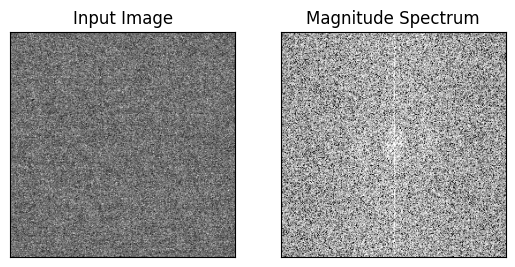

In [37]:
#first plot fft and the patch
i=1300
j=1200
step=2
tile=256
patch=getpatch(i,j,tile,step)
fft_patch2=fftpatch(patch)
np.savetxt("test1.txt",fft_patch2)
plt.subplot(121),plt.imshow(patch, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(fft_patch2, cmap = 'gray',norm=colors.LogNorm(vmin=1, vmax=200))
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

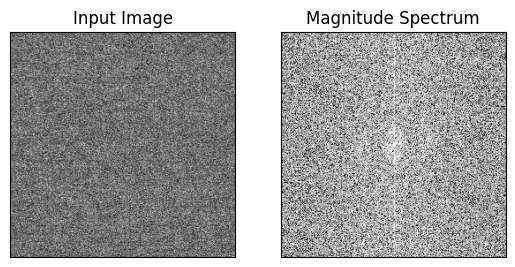

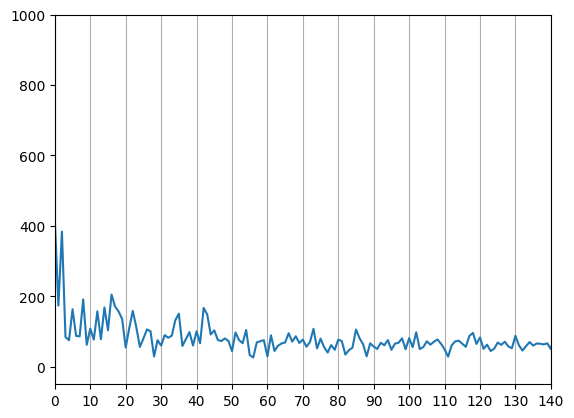

1.1609701966174963 331745.27974953566


In [38]:
#try for one point and pick a range for integration

#first plot fft and the patch
i=1301
j=1201
step=2
tile=256
patch=getpatch(i,j,tile,step)
fft_patch2=fftpatch(patch)
np.savetxt("test1.txt",fft_patch2)
plt.subplot(121),plt.imshow(patch, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(fft_patch2, cmap = 'gray',norm=colors.LogNorm(vmin=1, vmax=200))
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

#now plot radial profile

y,x = np.indices((fft_patch2.shape)) # first determine radii of all pixels
r = np.sqrt((x-tile/2)**2+(y-tile/2)**2)
ind = np.argsort(r.flat) # get sorted indices
sr = r.flat[ind] # sorted radii
sim = fft_patch2.flat[ind] # image values sorted by radii
sr=sr*4
ri = sr.astype(np.int32) # integer part of radii (bin size = 0.125)
ri=ri/4
    # determining distance between changes
deltar = ri[1:] - ri[:-1] # assume all radii represented
rind = np.where(deltar)[0] # location of changed radius
nr = rind[1:] - rind[:-1] # number in radius bin
csim = np.cumsum(sim, dtype=np.float64) # cumulative sum to figure out sums for each radii bin
tbin = csim[rind[1:]] - csim[rind[:-1]] # sum for image values in radius bins
radialprofile = tbin/nr # the answer
plt.plot(radialprofile)
plt.xlim(0,100)
plt.ylim(-50,1000)
plt.xticks(np.arange(0, 150, step=10))
plt.grid(visible=True, which='major', axis='x')
plt.show()
peak_d,peak_I=profpeak(fft_patch2,tile,19,25)
print(peak_d,peak_I)

In [ ]:
new_map1, new_map2=profpeakmap(128,8,15,18)
plt.subplot(121),plt.imshow(new_map1, cmap = 'gray')
plt.title('Spacing Map'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(new_map2, cmap = 'gray')
plt.title('Intensity Map'), plt.xticks([]), plt.yticks([])
plt.show()
np.savetxt("BF26_256_2_3_8_spacing.txt",new_map1)
np.savetxt("BF26_256_2_3_8_int.txt",new_map2)

In [7]:
from scipy import optimize
def gaussian(height, center_x, center_y, width, offset):
    """Returns a gaussian function with the given parameters"""
    width = float(width)
    return lambda x,y: offset + height*np.exp(
                -((((center_x-x)/width)**2+((center_y-y)/width)**2)/2))
def moments(data):
    """Returns (height, x, y, width, offset)
    the gaussian parameters of a 2D distribution by calculating its
    moments """
    total = data.sum()
    X, Y = np.indices(data.shape)
    x = (X*data).sum()/total
    y = (Y*data).sum()/total
    col = data[:, int(y)]
    width_x = np.sqrt(np.abs((np.arange(col.size)-x)**2*col).sum()/col.sum())
    row = data[int(x), :]
    width_y = np.sqrt(np.abs((np.arange(row.size)-y)**2*row).sum()/row.sum())
    width=min(width_x, width_y)
    height = data.max()
    offset=0
    return height, x, y, width, offset

def fitgaussian(data):
    """Returns (height, x, y, width, offset)
    the gaussian parameters of a 2D distribution found by a fit"""
    par = moments(data)
    errorfunction = lambda p: np.ravel(gaussian(*p)(*np.indices(data.shape)) -
                                 data)
    p, success = optimize.leastsq(errorfunction, par)
    return p

(256, 256)
808.57416 180 128 76 128
[6.09363704e+03 2.57721609e+00 3.17002625e+00 2.21233845e-01
 7.81068232e+01]
[6.49662837e+03 3.41472866e+00 2.73576788e+00 2.35820373e-01
 6.97978098e+01]


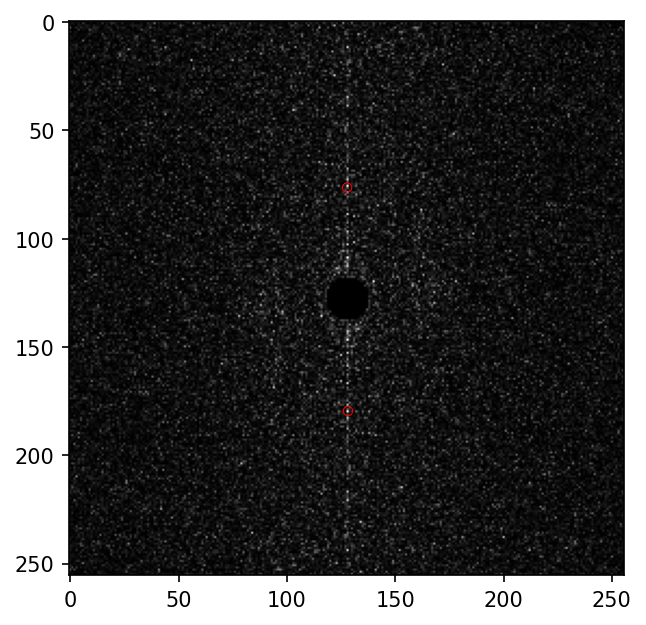

-89.75881713134522 103.16340142507184 0.19386720216399722


In [39]:
print(r.shape)
fft_patch1=fft_patch2
for i in range(0,tile):
    for j in range(0,tile):
        if (r[i,j]<10):
            fft_patch1[i,j]=0
max_patch=np.amax(fft_patch1)
for i in range(0,tile):
    for j in range(0,tile):
        if (fft_patch1[i,j]==max_patch):
            (ymax1,xmax1)=(i,j)
print(max_patch,ymax1,xmax1, tile-ymax1, tile-xmax1)
fit_rad=3
tmp1=fft_patch1[ymax1-fit_rad:ymax1+fit_rad,xmax1-fit_rad:xmax1+fit_rad]
params1 = fitgaussian(tmp1)
print(params1)
ymax2=tile-ymax1
xmax2=tile-xmax1
tmp2=fft_patch1[ymax2-fit_rad:ymax2+fit_rad,xmax2-fit_rad:xmax2+fit_rad]
params2 = fitgaussian(tmp2)
print(params2)
coordsY=(ymax1-fit_rad+params1[1],ymax2-fit_rad+params2[1])
coordsX=(xmax1-fit_rad+params1[2],xmax2-fit_rad+params2[2])
fig,ax = plt.subplots(1,dpi=150)
ax.imshow(fft_patch1,cmap='Greys_r')
ax.scatter(coordsX,coordsY,s=20,facecolor='none',edgecolor='r',linewidth=0.5)
plt.show()
if (xmax1<xmax2):
    angle=math.atan((coordsY[0]-coordsY[1])/(coordsX[1]-coordsX[0]))
else:
    angle=math.atan((coordsY[1]-coordsY[0])/(coordsX[0]-coordsX[1]))
distance=math.sqrt((coordsY[0]-coordsY[1])**2+(coordsX[0]-coordsX[1])**2)
dsp=1*(1/(distance*0.5))*10 
print(angle/math.pi*180,distance,dsp)

(256, 256)
[3.59724163e+03 3.19594375e+00 5.91698748e-01 2.24435771e-01
 8.09756076e+01]
[4.89483358e+02 1.00393845e+00 2.99965710e+00 1.09810849e-01
 6.14732130e+01]


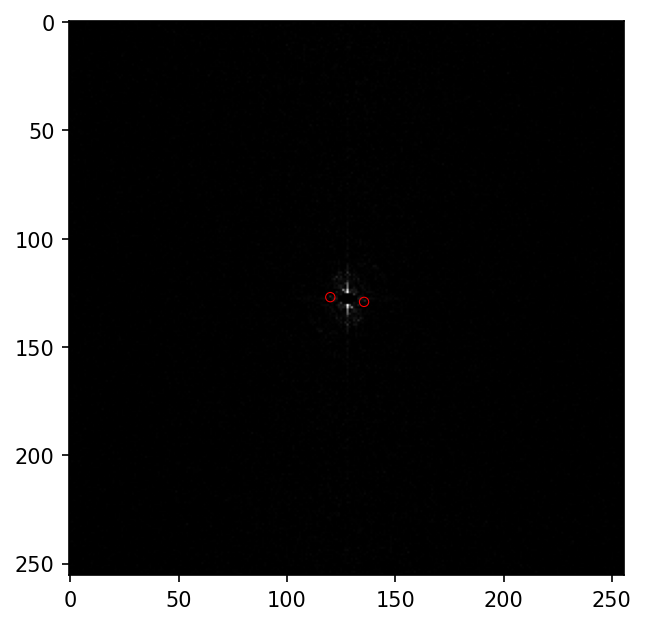

-8.002474693793813 15.745369156915187 1.2702147406443136


In [34]:
#different version with pre-set peak position

print(r.shape)
for i in range(0,tile):
    for j in range(0,tile):
        if (r[i,j]<3):
            fft_patch[i,j]=0
            
(ymax1,xmax1)=(128,137)
fit_rad=2
tmp1=fft_patch[ymax1-fit_rad:ymax1+fit_rad,xmax1-fit_rad:xmax1+fit_rad]
params1 = fitgaussian(tmp1)
print(params1)
ymax2=tile-ymax1
xmax2=tile-xmax1
tmp2=fft_patch[ymax2-fit_rad:ymax2+fit_rad,xmax2-fit_rad:xmax2+fit_rad]
params2 = fitgaussian(tmp2)
print(params2)
coordsY=(ymax1-fit_rad+params1[1],ymax2-fit_rad+params2[1])
coordsX=(xmax1-fit_rad+params1[2],xmax2-fit_rad+params2[2])
fig,ax = plt.subplots(1,dpi=150)
ax.imshow(fft_patch,cmap='Greys_r')
ax.scatter(coordsX,coordsY,s=20,facecolor='none',edgecolor='r',linewidth=0.5)
plt.show()
if (xmax1<xmax2):
    angle=math.atan((coordsY[0]-coordsY[1])/(coordsX[1]-coordsX[0]))
else:
    angle=math.atan((coordsY[1]-coordsY[0])/(coordsX[0]-coordsX[1]))
distance=math.sqrt((coordsY[0]-coordsY[1])**2+(coordsX[0]-coordsX[1])**2)
dsp=1*(1/(distance*0.5))*10 
print(angle/math.pi*180,distance,dsp)

In [9]:
def structuremaps(tile, step, rhighpass,fit_rad):
    #computes spacing, lattice orientation, and degree of crystallinity for each patch
    NgridX=int((NpixX-tile)/step + 1)
    NgridY=int((NpixY-tile)/step + 1)
    print(NgridX, NgridY)
    structure_maps=np.zeros((3,NgridX,NgridY))
    for k in range(3,NgridX-3) :
        print(k)
        for l in range(3,NgridY-3):
            patch=getpatch(k,l,tile,step)
            if (np.min(patch)==0):
                structure_maps[0,k,l]=0
                structure_maps[1,k,l]=0
                structure_maps[2,k,l]=0
            else:
                fft_patch=fftpatch(patch)
            
                for i in range(0,tile): #highpass filter the fft
                    for j in range(0,tile):
                        if (r[i,j]<rhighpass):
                            fft_patch[i,j]=0
                        
                max_patch=np.amax(fft_patch)  #find the peak and its symmetry twin
                for i in range(0,tile):
                    for j in range(0,tile):
                        if (fft_patch[i,j]==max_patch):
                            (ymax1,xmax1)=(i,j)
                if ((xmax1+fit_rad)>tile): xmax1=tile-fit_rad  #making sure small patch is within the big one
                if ((ymax1+fit_rad)>tile): ymax1=tile-fit_rad
                if ((xmax1-fit_rad)<0): xmax1=fit_rad 
                if ((ymax1-fit_rad)<0): ymax1=fit_rad 
                (ymax2,xmax2)=(tile-ymax1,tile-xmax1)

                tmp1=fft_patch[ymax1-fit_rad:ymax1+fit_rad,xmax1-fit_rad:xmax1+fit_rad] #fit the two peaks in small patches         
                params1 = fitgaussian(tmp1)
                #print(params1)
                tmp2=fft_patch[ymax2-fit_rad:ymax2+fit_rad,xmax2-fit_rad:xmax2+fit_rad]
                params2 = fitgaussian(tmp2)

                coordsY=(ymax1-fit_rad+params1[1],ymax2-fit_rad+params2[1]) #convert peak max into large patch coords
                coordsX=(xmax1-fit_rad+params1[2],xmax2-fit_rad+params2[2])

                if (xmax1<xmax2):    #compute dspacing, angle, and intensity and record into output
                    angle=math.atan((coordsY[0]-coordsY[1])/(coordsX[1]-coordsX[0]))
                else:
                    angle=math.atan((coordsY[1]-coordsY[0])/(coordsX[0]-coordsX[1]))
                distance=math.sqrt((coordsY[0]-coordsY[1])**2+(coordsX[0]-coordsX[1])**2)
                structure_maps[0,k,l]=1*(1/(distance*0.03125))*10
                structure_maps[1,k,l]=angle/math.pi*180
                structure_maps[2,k,l]=1/2*(np.mean(tmp1)+np.mean(tmp2))
                #print(structure_maps[:,k,l])
    return structure_maps


In [9]:
#alternative version where peak coords are set maniually
def structuremaps_set(tile, step, rhighpass,fit_rad, max_patchY, max_patchX):
    #computes spacing, lattice orientation, and degree of crystallinity for each patch
    NgridX=int((NpixX-tile)/step + 1)
    NgridY=int((NpixY-tile)/step + 1)
    print(NgridX, NgridY)
    structure_maps=np.zeros((3,NgridX,NgridY))
    for k in range(3,NgridX-3) :
        print(k)
        for l in range(3,NgridY-3):
            patch=getpatch(k,l,tile,step)
            if (np.min(patch)==0):
                structure_maps[0,k,l]=0
                structure_maps[1,k,l]=0
                structure_maps[2,k,l]=0
            else:
                fft_patch=fftpatch(patch)
            
                for i in range(0,tile): #highpass filter the fft
                    for j in range(0,tile):
                        if (r[i,j]<rhighpass):
                            fft_patch[i,j]=0
                        
                (ymax1,xmax1)=(max_patchY, max_patchX) #set the peak position
                (ymax2,xmax2)=(tile-ymax1,tile-xmax1)

                tmp1=fft_patch[ymax1-fit_rad:ymax1+fit_rad,xmax1-fit_rad:xmax1+fit_rad] #fit the two peaks in small patches         
                params1 = fitgaussian(tmp1)
                #print(params1)
                tmp2=fft_patch[ymax2-fit_rad:ymax2+fit_rad,xmax2-fit_rad:xmax2+fit_rad]
                params2 = fitgaussian(tmp2)

                coordsY=(ymax1-fit_rad+params1[1],ymax2-fit_rad+params2[1]) #convert peak max into large patch coords
                coordsX=(xmax1-fit_rad+params1[2],xmax2-fit_rad+params2[2])

                if (xmax1<xmax2):    #compute dspacing, angle, and intensity and record into output
                    angle=math.atan((coordsY[0]-coordsY[1])/(coordsX[1]-coordsX[0]))
                else:
                    angle=math.atan((coordsY[1]-coordsY[0])/(coordsX[0]-coordsX[1]))
                distance=math.sqrt((coordsY[0]-coordsY[1])**2+(coordsX[0]-coordsX[1])**2)
                structure_maps[0,k,l]=1*(1/(distance*0.03125))*10
                structure_maps[1,k,l]=angle/math.pi*180
                structure_maps[2,k,l]=1/2*(np.mean(tmp1)+np.mean(tmp2))
                #print(structure_maps[:,k,l])
    return structure_maps


In [40]:
new_map= structuremaps(256,2,10,3)
np.savetxt("BF37_256_2_10_3_spacing.txt",new_map[0,:,:])
np.savetxt("BF37_256_2_10_3_angle.txt",new_map[1,:,:])
np.savetxt("BF37_256_2_10_3_cryst.txt",new_map[2,:,:])

1921 1921
3


C:\Users\ayb\AppData\Local\Temp\ipykernel_16060\1468977807.py:30: RuntimeWarning: Number of calls to function has reached maxfev = 1200.
  p, success = optimize.leastsq(errorfunction, par)


4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
27

In [35]:
%cd "I:\\US200_data\\Nion Swift Project 20250725 Data\\analysis"
np.savetxt("BF36_256_2_10_3_spacing.txt",new_map[0,:,:])
np.savetxt("BF36_256_2_10_3_angle.txt",new_map[1,:,:])
np.savetxt("BF36_256_2_10_3_cryst.txt",new_map[2,:,:])

I:\US200_data\Nion Swift Project 20250725 Data\analysis


In [ ]:
cur_dir = r'D:\US200_data\Nion Swift Project 20240408 Data\analysis\LiMnCoO' #directory of image file%cd "K:\06Dec2023\analysis"
filename = 'SuperScan (c) 12.npy' #filename of image to analyze
for k in range(3,477) :
    for l in range(3,477):
        a=new_map[0,k,l]
        if (a!=0):
            a1=(1/(a*0.5))*20
            new_map[0,k,l]=a1
np.savetxt("ADF13_128_4_9_6_spacing.txt",new_map[0,:,:]) 

In [23]:
new_map=structuremaps(512,2,3,6)
plt.subplot(131),plt.imshow(new_map[0,:,:], cmap = 'gray')
plt.title('Spacing Map'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(new_map[1,:,:], cmap = 'gray')
plt.title('Angle Map'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(new_map[2,:,:], cmap = 'gray')
plt.title('Crystallinity Map'), plt.xticks([]), plt.yticks([])
plt.show()
np.savetxt("BF12_256_2_3_6_spacing.txt",new_map[0,:,:])
np.savetxt("BF12_256_2_3_6_angle.txt",new_map[1,:,:])
np.savetxt("BF12_256_2_3_6_cryst.txt",new_map[2,:,:])

NameError: name 'structuremaps' is not defined

In [ ]:
%cd "K:\US200_data\Nion Swift Project 20241115 Data\analysis\""
np.savetxt('BF31_128_8_4_6_spacing.txt',new_map[0,:,:])
np.savetxt("BF31_128_8_4_6_angle.txt",new_map[1,:,:])
np.savetxt("BF31_128_8_4_6_cryst.txt",new_map[2,:,:])

In [ ]:
%cd "D:\Albina\work\data\US200_data\Bishnu_carbon\Nion Swift Project 20241115 Data\analysis"
spacing=np.loadtxt('BF11_128_2_4_6_spacing.txt')
angle=np.loadtxt("BF11_128_2_4_6_angle.txt")
cryst=np.loadtxt("BF11_128_2_4_6_cryst.txt")

In [ ]:
plt.subplot(131),plt.imshow(new_map[0,:,:], cmap = 'gray')
plt.title('Spacing Map'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(new_map[1,:,:], cmap = 'gray')
plt.title('Angle Map'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(new_map[2,:,:], cmap = 'gray')
plt.title('Crystallinity Map'), plt.xticks([]), plt.yticks([])
plt.show()
np.savetxt("test1.txt",fft_patch)

In [ ]:
plt.subplot(131),plt.imshow(spacing[:,:], cmap = 'gray')
plt.title('Spacing Map'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(angle[:,:], cmap = 'gray')
plt.title('Angle Map'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(cryst[:,:], cmap = 'gray')
plt.title('Crystallinity Map'), plt.xticks([]), plt.yticks([])
plt.show()

In [ ]:
tmp10=numpy.loadtxt("Map_BF10_128_8_7_4_2.txt")
print(median(tmp10))

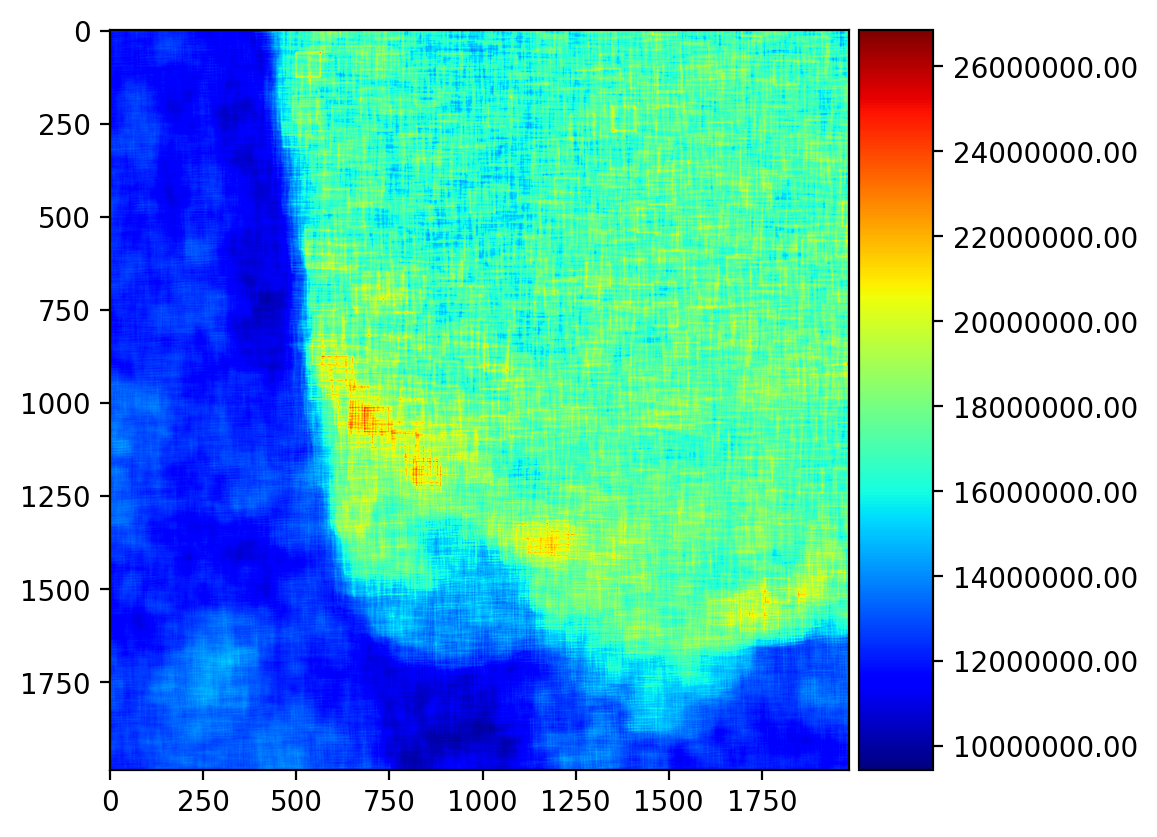

In [ ]:
newdata=fftintmap(128,2,39,42)
fig,ax = plt.subplots(1,dpi=200)
im=ax.imshow(newdata,cmap='jet')
divider = make_axes_locatable(ax)
# Append axes to the right of ax3, with 10% width of ax
cax = divider.append_axes("right", size="10%", pad=0.05)
plt.colorbar(im, cax = cax, format="%.2f")
ax.imshow(newdata,cmap='jet')
plt.show()

In [ ]:
np.save("8to11.npy",newdata)